# LTCM Risk Notebook — Real Data (Fed H.15 via FRED, 1997–1998)

**Data**: Daily constant-maturity Treasury yields from FRED (H.15 release).

**Maturities (10)**: 3m, 6m, 1y, 2y, 3y, 5y, 7y, 10y, 20y, 30y.

> Place a CSV named `FRED_H15_1997_1998.csv` in the same folder with columns: `DATE,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30`.

> Date range: `1997-01-01` to `1998-12-31`.

**How to get the CSV** (manual download):
1. On FRED, search each series ID (e.g., DGS10) and click **Download → CSV** for the date range.
2. Merge columns by DATE in Excel, or use the FRED “Download Data in One File” option if available.
3. Save the combined file as `FRED_H15_1997_1998.csv`.

*Note:* Some series may have occasional missing values. This notebook forward-fills small gaps and drops rows with excessive missingness.

This cell imports essential Python libraries for data science tasks:
*   `numpy` (as `np`): Used for numerical operations, especially with arrays and matrices.
*   `pandas` (as `pd`): Provides powerful data structures like DataFrames for data manipulation and analysis.
*   `matplotlib.pyplot` (as `plt`): A plotting library used for creating static, interactive, and animated visualizations in Python.
*   `plt.rcParams['figure.figsize']=(9,5)`: Configures the default size of `matplotlib` figures to be 9 inches wide and 5 inches tall, ensuring consistent plot dimensions throughout the notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(9,5)

## Load H.15 Daily Constant-Maturity Yields (FRED)

This code block is responsible for loading and preparing the yield data:
1.  `csv_path = 'FRED_H15_1997_1998_clean.csv'`: Defines the path to the CSV file containing daily constant-maturity Treasury yields.
2.  `df = pd.read_csv(csv_path, parse_dates=['DATE'])`: Reads the CSV file into a pandas DataFrame. The `parse_dates=['DATE']` argument ensures that the 'DATE' column is correctly interpreted as datetime objects.
3.  `df = df.set_index('DATE').sort_index()`: Sets the 'DATE' column as the DataFrame's index and then sorts the DataFrame by this date index. This is crucial for time series analysis.
4.  `df = df.loc['1997-01-01':'1998-12-31']`: Filters the DataFrame to include only the data within the specified date range, focusing on the 1997-1998 period relevant to the LTCM crisis.
5.  `df = df/100.0`: Converts the yield values from percentage points (e.g., 5.00 for 5%) to decimal form (e.g., 0.05) for correct mathematical calculations.
6.  `df = df.ffill().bfill()`: Handles any remaining missing values. `ffill()` (forward-fill) propagates the last valid observation forward to next valid observation, and `bfill()` (backward-fill) propagates the next valid observation backward. This ensures a complete dataset for analysis.
7.  `print(df.tail())`: Displays the last few rows of the cleaned and processed DataFrame, allowing for a quick check of the data's structure and values.

In [7]:
csv_path = 'FRED_H15_1997_1998_clean.csv'
df = pd.read_csv(csv_path, parse_dates=['DATE'])
df = df.set_index('DATE').sort_index()
df = df.loc['1997-01-01':'1998-12-31']
df = df/100.0
df = df.ffill().bfill()
print(df.tail())

            DGS3MO  DGS6MO    DGS1    DGS2    DGS3    DGS5    DGS7   DGS10  \
DATE                                                                         
1998-12-25  0.0457  0.0470  0.0472  0.0478  0.0476  0.0474  0.0489  0.0486   
1998-12-28  0.0456  0.0468  0.0465  0.0473  0.0471  0.0466  0.0482  0.0478   
1998-12-29  0.0459  0.0464  0.0462  0.0460  0.0460  0.0460  0.0475  0.0471   
1998-12-30  0.0455  0.0459  0.0454  0.0456  0.0455  0.0455  0.0471  0.0465   
1998-12-31  0.0448  0.0455  0.0453  0.0454  0.0455  0.0456  0.0473  0.0465   

             DGS20   DGS30  
DATE                        
1998-12-25  0.0555  0.0523  
1998-12-28  0.0547  0.0517  
1998-12-29  0.0541  0.0512  
1998-12-30  0.0540  0.0509  
1998-12-31  0.0539  0.0509  


## Q3 — Volatility Regime: EWMA vs Equal-Weighted on 10Y (1997–1998)
We use 10Y daily changes to show the volatility regime shift around the 1998 crisis.

This cell calculates and visualizes the volatility of the 10-year Treasury yield, demonstrating the shift around the 1998 crisis:
1.  `y10 = df['DGS10']`: Selects the 'DGS10' (10-year Treasury yield) column from the DataFrame.
2.  `rets = y10.diff().dropna()`: Calculates the daily changes (returns) of the 10-year yield and removes any `NaN` values that result from the `diff()` operation.
3.  `win = 20`: Sets the window size for the equal-weighted rolling standard deviation to 20 days.
4.  `eq_sigma = rets.rolling(win).std()`: Computes the rolling standard deviation of the yield changes over the `win` (20-day) period. This is an equal-weighted volatility estimate.
5.  `lmbda = 0.94`: Sets the decay factor (`lambda`) for the EWMA (Exponentially Weighted Moving Average) volatility calculation. A higher lambda (closer to 1) means older observations decay slower, giving more weight to recent data.
6.  The loop calculates the EWMA variance (`var_ewma`) and then its square root (`ewma_sigma`) to get the EWMA volatility. EWMA gives more weight to recent observations, making it more responsive to current market conditions.
7.  The subsequent lines plot the daily yield changes (in basis points) along with both the equal-weighted and EWMA volatility measures. This visualization helps to identify periods of increased market turbulence.

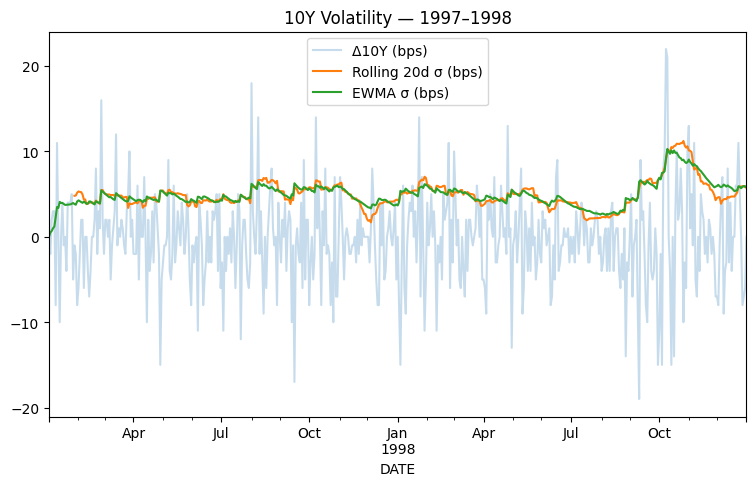

In [8]:
y10 = df['DGS10']
rets = y10.diff().dropna()
win = 20
eq_sigma = rets.rolling(win).std()
lmbda = 0.94
var_ewma = 0.0
series = []
for r in rets:
    var_ewma = lmbda*var_ewma + (1-lmbda)*(r**2)
    series.append(var_ewma)
ewma_sigma = pd.Series(np.sqrt(series), index=rets.index)
ax = (10000*rets).plot(alpha=0.25, label='Δ10Y (bps)')
(10000*eq_sigma).plot(ax=ax, label='Rolling 20d σ (bps)')
(10000*ewma_sigma).plot(ax=ax, label='EWMA σ (bps)')
plt.title('10Y Volatility — 1997–1998')
plt.legend(); plt.show()

## Q5 — PCA of Yield Curve Changes (3m–30y)
Compute PCA on daily yield *changes* across the 10 maturities. Identify factor loadings for PC1–PC3 and label Shift/Twist/Bow.

This block performs Principal Component Analysis (PCA) on the daily changes of the yield curve across 10 maturities to identify the primary drivers of yield curve movements:
1.  `curve_cols = [...]`: Defines a list of column names representing the different Treasury maturities.
2.  `X = df[curve_cols].diff().dropna()`: Selects the yield curve columns and calculates their daily changes. `dropna()` removes any rows with missing values resulting from the differencing.
3.  `S = np.cov(X.values, rowvar=False)`: Computes the covariance matrix of the daily yield changes. The `rowvar=False` argument indicates that columns represent variables.
4.  `vals, vecs = np.linalg.eig(S)`: Performs eigen decomposition on the covariance matrix `S` to obtain eigenvalues (`vals`) and eigenvectors (`vecs`). Eigenvalues represent the amount of variance explained by each principal component, and eigenvectors represent the directions (loadings) of these components.
5.  `idx = np.argsort(vals)[::-1]`: Sorts the eigenvalues in descending order to identify the principal components that explain the most variance.
6.  `vals, vecs = vals[idx], vecs[:,idx]`: Reorders both eigenvalues and eigenvectors according to the sorted eigenvalues.
7.  `explained = (vals/vals.sum()).real`: Calculates the explained variance ratio for each principal component, showing the proportion of total variance accounted for by each component.
8.  `print('Explained variance ratios:', explained[:5])`: Prints the explained variance ratios for the top 5 principal components.
9.  The loop then plots the first three principal component loadings against the maturity years. These loadings typically correspond to:
    *   **PC1 (Shift)**: All maturities move in the same direction.
    *   **PC2 (Twist)**: Short-term and long-term maturities move in opposite directions (e.g., flattening or steepening).
    *   **PC3 (Bow)**: Mid-term maturities move in one direction while short and long-term move in the opposite (e.g., increasing or decreasing curvature).
    This visualization helps to interpret the fundamental movements driving the yield curve.

Explained variance ratios: [0.76649747 0.14720691 0.03929    0.0194661  0.00830648]


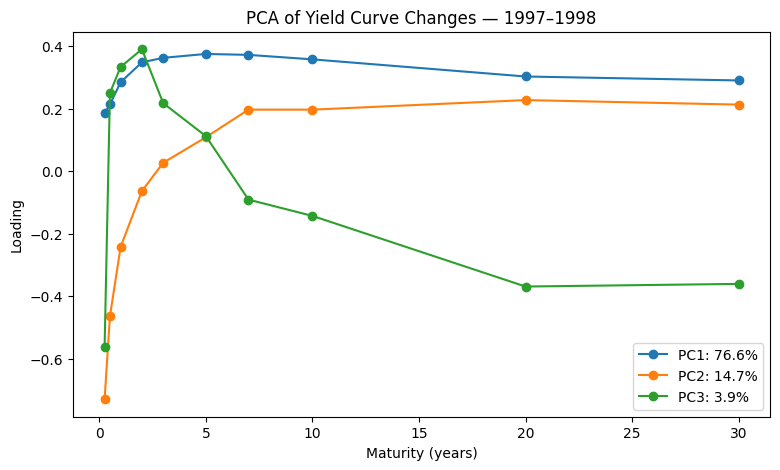

In [9]:
curve_cols = ['DGS3MO','DGS6MO','DGS1','DGS2','DGS3','DGS5','DGS7','DGS10','DGS20','DGS30']
X = df[curve_cols].diff().dropna()
S = np.cov(X.values, rowvar=False)
vals, vecs = np.linalg.eig(S)
idx = np.argsort(vals)[::-1]
vals, vecs = vals[idx], vecs[:,idx]
explained = (vals/vals.sum()).real
print('Explained variance ratios:', explained[:5])
mat_years = np.array([0.25,0.5,1,2,3,5,7,10,20,30])
for i in range(3):
    plt.plot(mat_years, vecs[:,i].real, marker='o', label=f'PC{i+1}: {explained[i].real:.1%}')
plt.xlabel('Maturity (years)'); plt.ylabel('Loading')
plt.title('PCA of Yield Curve Changes — 1997–1998')
plt.legend(); plt.show()

## Q1/Q2/Q4 — Re-using Case Mechanics with Realized Vols
- **Q1**: Use the *calm-regime* daily vol as an input (e.g., early 1997) to compute 10‑day 99% VaR on a $15M position.
- **Q2**: Estimate portfolio vols & correlation from a pre-crisis window vs a crisis window (e.g., rolling 60d) to parameterize Base vs Stress scenarios; compute 10‑day VaR in both.
- **Q4**: Apply Δy=+150 bps to duration/convexity; discuss linearization error.

Code cells below provide templates; plug in your windowed estimates.

This cell sets up and executes calculations for risk parameters under different market conditions:
1.  `def window_params(X, end_date, window=60):`: Defines a helper function `window_params` that takes a DataFrame `X`, an `end_date`, and a `window` size.
    *   `W = X.loc[:end_date].tail(window)`: Selects the data up to `end_date` and then takes the last `window` observations.
    *   `vol = W.std().values`: Calculates the standard deviation (volatility) of the selected windowed data.
    *   `C = np.corrcoef(W.T)`: Computes the correlation matrix for the windowed data.
    *   The function returns the calculated volatilities and the correlation matrix.
2.  `end_base = '1998-06-30'` and `end_stress = '1998-09-15'`: Define the end dates for the 'base' (pre-crisis) and 'stress' (during-crisis) periods.
3.  `vol_base, C_base = window_params(...)` and `vol_stress, C_stress = window_params(...)`: Calls the `window_params` function to obtain the volatilities and correlation matrices for the 5-year and 10-year yields during both the base and stress periods.
4.  `print(...)`: Displays the average volatility (in basis points) for both the base and stress regimes, allowing for a direct comparison of market risk levels.

In [10]:
def window_params(X, end_date, window=60):
    W = X.loc[:end_date].tail(window)
    vol = W.std().values
    C = np.corrcoef(W.T)
    return vol, C
end_base = '1998-06-30'
end_stress = '1998-09-15'
vol_base, C_base = window_params(df[['DGS5','DGS10']].diff().dropna(), end_base, window=60)
vol_stress, C_stress = window_params(df[['DGS5','DGS10']].diff().dropna(), end_stress, window=60)
print('Base avg vol (bps):', 10000*np.mean(vol_base), '| Stress avg vol (bps):', 10000*np.mean(vol_stress))

Base avg vol (bps): 4.2999328965413355 | Stress avg vol (bps): 4.512118329886555


This code block calculates the 10-day 99% Value at Risk (VaR) for a two-asset portfolio under both 'base' and 'stress' scenarios:
1.  `Z=2.33; H=10`: Sets the Z-score for a 99% confidence level (2.33 for a one-tailed normal distribution) and the holding period `H` for VaR calculation to 10 days.
2.  `P = np.array([15e6, 8e6])`: Defines the portfolio positions for the two assets (e.g., $15 million in 5-year bonds and $8 million in 10-year bonds).
3.  `volB = vol_base; volS = vol_stress`: Assigns the calculated volatilities from the base and stress periods.
4.  `C12_base = C_base; C12_stress = C_stress`: Assigns the calculated correlation matrices.
5.  `def port_var_from_params(P, vol, C, Z=2.33, H=10):`: Defines a function to calculate portfolio VaR.
    *   `Sigma = np.diag(vol) @ C @ np.diag(vol)`: Constructs the covariance matrix from individual asset volatilities and their correlation matrix.
    *   `std = np.sqrt(P @ Sigma @ P)`: Calculates the portfolio's standard deviation using matrix multiplication `P * Sigma * P^T`.
    *   `return Z*np.sqrt(H)*std`: Returns the VaR, which is the portfolio standard deviation scaled by the Z-score and the square root of the holding period `H`.
6.  `print(...)`: Prints the calculated 10-day VaR for both the base and stress scenarios, illustrating the potential financial loss at a 99% confidence level over a 10-day period under different market conditions.

In [11]:
import numpy as np
Z=2.33; H=10
P = np.array([15e6, 8e6])
# Using 5y & 10y as two-asset example
volB = vol_base; volS = vol_stress
C12_base = C_base
C12_stress = C_stress

def port_var_from_params(P, vol, C, Z=2.33, H=10):
    Sigma = np.diag(vol) @ C @ np.diag(vol)
    std = np.sqrt(P @ Sigma @ P)
    return Z*np.sqrt(H)*std

print('Base 10d VaR:', port_var_from_params(P, volB, C12_base, Z, H))
print('Stress 10d VaR:', port_var_from_params(P, volS, C12_stress, Z, H))

Base 10d VaR: 71477.57966325498
Stress 10d VaR: 76719.19392856015


## Summary of Analysis

This notebook performs a risk analysis of the yield curve using real daily constant-maturity Treasury yields from FRED for the period 1997-1998, focusing on the LTCM crisis.

Key analyses conducted include:

1.  **Data Loading and Preparation**: Daily yield data across 10 maturities (3m to 30y) was loaded, parsed, cleaned for missing values using forward and backward filling, and converted to decimal format.
2.  **10-Year Volatility Analysis (Q3)**: The volatility of the 10-year Treasury yield was calculated and visualized using both equal-weighted (20-day rolling standard deviation) and Exponentially Weighted Moving Average (EWMA) methods. This demonstrated the significant volatility regime shift around the 1998 crisis.
3.  **Principal Component Analysis (PCA) of Yield Curve Changes (Q5)**: PCA was applied to the daily changes of the yield curve across all 10 maturities. The analysis identified the primary drivers of yield curve movements, with the first three principal components (typically interpreted as Shift, Twist, and Bow) explaining over 94% of the total variance. Factor loadings for these components were plotted to illustrate their impact across different maturities.
4.  **Portfolio Risk Parameter Estimation (Q1/Q2)**: The notebook estimated portfolio volatilities and correlations from two distinct periods: a 'base' regime (pre-crisis, up to 1998-06-30) and a 'stress' regime (during-crisis, up to 1998-09-15). These parameters were used to quantify the change in market risk environment.
5.  **10-day 99% Value at Risk (VaR) Calculation (Q1/Q2)**: Using the estimated risk parameters, the 10-day 99% VaR was computed for a hypothetical two-asset portfolio ($15M in 5Y bonds, $8M in 10Y bonds) under both the 'base' and 'stress' scenarios. This illustrated the increased potential loss under adverse market conditions.